# TP2 - Taller de Programación - Grupo 6

**Métodos no supervisados usando la EPH - 4.º trimestre de 2024 y 2025**

Arias Christian

Avila Leonardo

Enrique Vallejo


## 0. Librerías y configuración



In [1]:
# ============================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN GENERAL
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, balanced_accuracy_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

SEMILLA = 123
COLORES_FORMALIDAD = {
    "Formal": "#2E86AB",
    "Informal upper-tier": "#F18F01",
}

CARPETA = Path(".")
ARCHIVO_2024 = CARPETA / "usu_individual_T424.xlsx"
ARCHIVO_2025 = CARPETA / "usu_individual_T425.xlsx"
CARPETA_SALIDA = CARPETA / "salidas_tp2_corregido"
CARPETA_SALIDA.mkdir(exist_ok=True)

for archivo in [ARCHIVO_2024, ARCHIVO_2025]:
    if not archivo.exists():
        raise FileNotFoundError(
            f"No se encontró {archivo.name}. Coloque la base en la misma carpeta del notebook."
        )


## Parte I. Creación de variables y estadística descriptiva

### 1. Lectura, limpieza y armonización

Mantenemos las 20 variables del TP1, las variables de identificación y las variables necesarias para construir educación, horas trabajadas y tamaño del hogar.


In [2]:
# ============================================================
# 1. VARIABLES NECESARIAS Y LECTURA DE LAS BASES
# ============================================================

VARIABLES_ID = [
    "CODUSU", "ANO4", "TRIMESTRE", "NRO_HOGAR", "COMPONENTE",
    "H15", "REGION", "MAS_500", "AGLOMERADO", "PONDERA",
]

VARIABLES_TP1 = [
    "CH04", "CH06", "CH07", "CH08", "NIVEL_ED", "ESTADO", "CAT_OCUP",
    "EMPLEO", "SECTOR", "PP04C", "PP04D_COD", "P21", "P47T", "CH03",
    "INTENSI", "PP04A", "PP04B_COD", "PP04G", "PP07H", "PP07I",
]

VARIABLES_NUEVAS_FUENTE = [
    "CH12", "CH13", "CH14", "PP3E_TOT", "PP3F_TOT",
]

VARIABLES_PONDERADORES_INGRESO = ["PONDIIO", "PONDII"]

VARIABLES_A_LEER = (
    VARIABLES_ID
    + VARIABLES_TP1
    + VARIABLES_NUEVAS_FUENTE
    + VARIABLES_PONDERADORES_INGRESO
)


def leer_base(archivo, columnas):
    """Lee únicamente las columnas necesarias."""
    try:
        return pd.read_excel(archivo, usecols=columnas, engine="openpyxl")
    except ValueError as error:
        raise ValueError(
            f"Faltan columnas necesarias en {archivo.name}. Revise los nombres."
        ) from error


eph24_original = leer_base(ARCHIVO_2024, VARIABLES_A_LEER)
eph25_original = leer_base(ARCHIVO_2025, VARIABLES_A_LEER)

assert set(eph24_original["ANO4"].dropna().unique()) == {2024}
assert set(eph25_original["ANO4"].dropna().unique()) == {2025}
assert set(eph24_original["TRIMESTRE"].dropna().unique()) == {4}
assert set(eph25_original["TRIMESTRE"].dropna().unique()) == {4}

print("Dimensiones leídas:")
print("2024T4:", eph24_original.shape)
print("2025T4:", eph25_original.shape)


Dimensiones leídas:
2024T4: (46860, 37)
2025T4: (43703, 37)


In [3]:
# ============================================================
# 2. LIMPIEZA Y ARMONIZACIÓN
# ============================================================


def limpiar_y_armonizar(base):
    df = base.copy()

    # Identificadores de texto.
    df["CODUSU"] = df["CODUSU"].astype("string")
    df["MAS_500"] = df["MAS_500"].astype("string")

    # Todas las demás columnas, salvo el código CNO, se llevan a numérico.
    columnas_numericas = [
        columna for columna in VARIABLES_A_LEER
        if columna not in ["CODUSU", "MAS_500", "PP04D_COD"]
    ]

    for columna in columnas_numericas:
        df[columna] = pd.to_numeric(df[columna], errors="coerce")

    # CH06 = -1 identifica a menores de un año.
    df.loc[df["CH06"] == -1, "CH06"] = 0
    df.loc[~df["CH06"].between(0, 110), "CH06"] = np.nan

    # Códigos de no respuesta o no correspondencia.
    codigos_a_nan = {
        "CH07": [9],
        "CH08": [9],
        "CH12": [0, 99],
        "CH13": [0, 9],
        "CH14": [98, 99],
        "NIVEL_ED": [9],
        "CAT_OCUP": [0, 9],
        "EMPLEO": [9],
        "SECTOR": [9],
        "PP04C": [0, 99],
        "INTENSI": [9],
        "PP04A": [0, 9],
        "PP04B_COD": [0, 9999, 99999],
        "PP04G": [0, 99],
        "PP07H": [0, 9],
        "PP07I": [0, 9],
    }

    for variable, codigos in codigos_a_nan.items():
        df.loc[df[variable].isin(codigos), variable] = np.nan

    # Horas semanales. El código 999 queda fuera del rango válido.
    for variable in ["PP3E_TOT", "PP3F_TOT"]:
        df.loc[~df[variable].between(0, 168), variable] = np.nan

    # Código de ocupación: texto de cinco caracteres.
    cno = pd.to_numeric(df["PP04D_COD"], errors="coerce")
    cno = cno.mask(cno.isin([99997, 99998, 99999]))
    df["PP04D_COD"] = cno.astype("Int64").astype("string").str.zfill(5)

    # Ingresos: los valores negativos son códigos especiales; cero es válido.
    for variable in ["P21", "P47T"]:
        df.loc[df[variable] < 0, variable] = np.nan
        df[variable] = df[variable].astype("float64")

    # Tipos enteros anulables para los códigos numéricos.
    columnas_enteras = [
        columna for columna in columnas_numericas
        if columna not in ["P21", "P47T", "PP3E_TOT", "PP3F_TOT"]
    ]

    for columna in columnas_enteras:
        df[columna] = df[columna].round().astype("Int64")

    return df


eph24 = limpiar_y_armonizar(eph24_original)
eph25 = limpiar_y_armonizar(eph25_original)

# Control de tipos entre años.
tipos = pd.DataFrame({
    "2024": eph24[VARIABLES_A_LEER].dtypes.astype(str),
    "2025": eph25[VARIABLES_A_LEER].dtypes.astype(str),
})
tipos["Coinciden"] = tipos["2024"] == tipos["2025"]
display(tipos)
assert tipos["Coinciden"].all()


,2024,2025,Coinciden
CODUSU,string,string,True
ANO4,Int64,Int64,True
TRIMESTRE,Int64,Int64,True
NRO_HOGAR,Int64,Int64,True
COMPONENTE,Int64,Int64,True
H15,Int64,Int64,True
REGION,Int64,Int64,True
MAS_500,string,string,True
AGLOMERADO,Int64,Int64,True
PONDERA,Int64,Int64,True


### 1.a-1.d. Nuevas variables

- `edad2`: edad al cuadrado.
- `educ`: aproximación a años de educación formal usando nivel, finalización y último año aprobado.
- `horastrab`: horas semanales propias, sumando ocupación principal y otras ocupaciones.
- `horastrabj`: horas del jefe o jefa, asignadas a todos los miembros del mismo hogar. Esto permite usar la variable en la base de ocupados sin eliminar automáticamente a quienes no son jefes.
- `nhogar`: cantidad de componentes distintos del hogar.


In [4]:
# ============================================================
# 3. CREACIÓN DE EDAD2, EDUC, HORASTRAB, HORASTRABJ Y NHOGAR
# ============================================================


def crear_anios_educacion(df):
    """Aproxima años de educación formal con CH12, CH13 y CH14."""
    educ = pd.Series(np.nan, index=df.index, dtype="float64")

    # Años totales aproximados cuando el nivel fue finalizado.
    anios_completos = {
        1: 0,   # Jardín/preescolar
        2: 6,   # Primario
        3: 9,   # EGB
        4: 12,  # Secundario
        5: 12,  # Polimodal
        6: 15,  # Terciario
        7: 17,  # Universitario
        8: 19,  # Posgrado
    }

    # Años acumulados antes de comenzar cada nivel.
    anios_previos = {
        1: 0, 2: 0, 3: 0, 4: 6, 5: 9, 6: 12, 7: 12, 8: 17,
    }

    # Máximo plausible para una persona que declara no haber terminado el nivel.
    maximo_incompleto = {
        1: 0, 2: 5, 3: 8, 4: 11, 5: 11, 6: 14, 7: 16, 8: 18,
    }

    for nivel, total in anios_completos.items():
        mascara = (df["CH12"] == nivel) & (df["CH13"] == 1)
        educ.loc[mascara] = total

    for nivel, base_previa in anios_previos.items():
        mascara = (
            (df["CH12"] == nivel)
            & (df["CH13"] == 2)
            & df["CH14"].between(0, 9)
        )
        valor = base_previa + df.loc[mascara, "CH14"].astype(float)
        educ.loc[mascara] = valor.clip(upper=maximo_incompleto[nivel])

    # Educación especial (CH12 = 9) no se convierte a una escala comparable.
    return educ


def crear_variables_tp2(base):
    df = base.copy()

    # Edad y edad al cuadrado.
    df["edad"] = df["CH06"].astype("Float64")
    df["edad2"] = df["edad"] ** 2

    # Años de educación.
    df["educ"] = crear_anios_educacion(df)

    # Horas propias de cada persona ocupada.
    df["horastrab"] = df[["PP3E_TOT", "PP3F_TOT"]].sum(
        axis=1,
        min_count=1,
    )
    df.loc[~df["horastrab"].between(0, 168), "horastrab"] = np.nan

    # Horas del jefe o jefa, propagadas a todo el hogar.
    claves_hogar = ["CODUSU", "NRO_HOGAR"]
    horas_del_jefe = df["horastrab"].where(df["CH03"] == 1)
    df["horastrabj"] = horas_del_jefe.groupby(
        [df["CODUSU"], df["NRO_HOGAR"]]
    ).transform("max")

    # Número de miembros por hogar.
    df["nhogar"] = (
        df.groupby(claves_hogar)["COMPONENTE"]
        .transform("nunique")
        .astype("Int64")
    )

    return df


eph24 = crear_variables_tp2(eph24)
eph25 = crear_variables_tp2(eph25)

# Controles básicos.
assert (eph24["edad2"].dropna() == eph24["edad"].dropna() ** 2).all()
assert (eph25["edad2"].dropna() == eph25["edad"].dropna() ** 2).all()
assert eph24["nhogar"].min() >= 1
assert eph25["nhogar"].min() >= 1


### Reconstrucción de las bases del TP1 e informalidad

Los ingresos de 2024 se expresan en pesos de 2025T4 con el mismo factor usado en el TP1. Después se construyen `respondieron`, `norespondieron` y `ocupados`.


In [5]:
# ============================================================
# 4. INGRESOS, SUBBASES Y DUMMIES DEL TP1
# ============================================================

eph = pd.concat([eph24, eph25], ignore_index=True)

FACTOR_IPC_2024T4_A_2025T4 = 1.314106232

eph["P21_NOMINAL"] = eph["P21"]
eph["P47T_NOMINAL"] = eph["P47T"]

mascara_2024 = eph["ANO4"] == 2024
eph.loc[mascara_2024, "P21"] = (
    eph.loc[mascara_2024, "P21"] * FACTOR_IPC_2024T4_A_2025T4
)
eph.loc[mascara_2024, "P47T"] = (
    eph.loc[mascara_2024, "P47T"] * FACTOR_IPC_2024T4_A_2025T4
)

respondieron = eph[eph["ESTADO"] != 0].copy()
norespondieron = eph[eph["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Respondieron por año:")
display(respondieron.groupby("ANO4").size().to_frame("Observaciones"))
print("Ocupados por año:")
display(ocupados.groupby("ANO4").size().to_frame("Observaciones"))


def crear_dummy(serie, valores_que_valen_uno):
    resultado = pd.Series(pd.NA, index=serie.index, dtype="Int64")
    observados = serie.notna()
    resultado.loc[observados] = (
        serie.loc[observados].isin(valores_que_valen_uno).astype("int64")
    )
    return resultado


ocupados["mujer"] = crear_dummy(ocupados["CH04"], [2])
ocupados["casado"] = crear_dummy(ocupados["CH07"], [2])
ocupados["unido_o_casado"] = crear_dummy(ocupados["CH07"], [1, 2])
ocupados["con_cobertura_medica"] = crear_dummy(
    ocupados["CH08"], [1, 2, 3, 12, 13, 23, 123]
)
ocupados["secundario_completo_o_mas"] = crear_dummy(
    ocupados["NIVEL_ED"], [4, 5, 6]
)
ocupados["asalariado"] = crear_dummy(ocupados["CAT_OCUP"], [3])
ocupados["cuenta_propia"] = crear_dummy(ocupados["CAT_OCUP"], [2])
ocupados["empleo_informal_eph"] = crear_dummy(ocupados["EMPLEO"], [2])
ocupados["sector_informal"] = crear_dummy(ocupados["SECTOR"], [2])
ocupados["sector_publico"] = crear_dummy(ocupados["PP04A"], [1])
ocupados["ocupado_pleno"] = crear_dummy(ocupados["INTENSI"], [2])
ocupados["con_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [1])
ocupados["sin_descuento_jubilatorio"] = crear_dummy(ocupados["PP07H"], [2])

VARIABLES_DUMMY_TP1 = [
    "mujer", "casado", "unido_o_casado", "con_cobertura_medica",
    "secundario_completo_o_mas", "asalariado", "cuenta_propia",
    "empleo_informal_eph", "sector_informal", "sector_publico",
    "ocupado_pleno", "con_descuento_jubilatorio",
    "sin_descuento_jubilatorio",
]


Respondieron por año:


,Observaciones
ANO4,
2024,46804
2025,43638


Ocupados por año:


,Observaciones
ANO4,
2024,21132
2025,19698


In [6]:
# ============================================================
# 5. INFORMALIDAD DEL GRUPO 6
# ============================================================

ocupados["informal"] = pd.Series(pd.NA, index=ocupados.index, dtype="Int64")

# Asalariados formales.
mascara_formal = (
    (ocupados["CAT_OCUP"] == 3)
    & (ocupados["PP07H"] == 1)
)

# Asalariados informales upper-tier.
mascara_informal = (
    (ocupados["CAT_OCUP"] == 3)
    & (ocupados["PP07H"] == 2)
    & ocupados["PP04C"].between(6, 12)
)

ocupados.loc[mascara_formal, "informal"] = 0
ocupados.loc[mascara_informal, "informal"] = 1
ocupados["grupo_informalidad"] = ocupados["informal"].map({
    0: "Formal",
    1: "Informal upper-tier",
})

# Esta base se usa cuando la consigna exige comparar formalidad e informalidad.
base_clasificada = ocupados.dropna(subset=["informal"]).copy()
base_clasificada["informal"] = base_clasificada["informal"].astype("int64")

print("Cobertura de la clasificación del Grupo 6:")
display(
    base_clasificada
    .groupby(["ANO4", "grupo_informalidad"])
    .size()
    .unstack(fill_value=0)
)


Cobertura de la clasificación del Grupo 6:


grupo_informalidad,Formal,Informal upper-tier
ANO4,,
2024,9727,1578
2025,8815,1377


### 2. Estadística descriptiva

La tabla se calcula sobre `respondieron`, igual que la tabla principal del TP1. Esto evita restringirla a jefes, asalariados o personas clasificables


In [7]:
# ============================================================
# 6. ESTADÍSTICA DESCRIPTIVA
# ============================================================


def tabla_descriptiva(base, variables):
    datos = base[variables].copy()

    for variable in variables:
        datos[variable] = pd.to_numeric(datos[variable], errors="coerce")

    tabla = datos.describe(percentiles=[0.25, 0.50, 0.75]).T
    tabla = tabla.rename(columns={
        "count": "Observaciones",
        "mean": "Promedio",
        "std": "Desvío estándar",
        "min": "Mínimo",
        "25%": "P25",
        "50%": "P50",
        "75%": "P75",
        "max": "Máximo",
    })

    orden = [
        "Observaciones", "Promedio", "Desvío estándar", "Mínimo",
        "P25", "P50", "P75", "Máximo",
    ]
    return tabla[orden]


VARIABLES_NUEVAS_NUMERICAS = [
    "edad2", "educ", "horastrab", "horastrabj", "nhogar",
]
VARIABLES_DESCRIPTIVAS = VARIABLES_TP1 + VARIABLES_NUEVAS_NUMERICAS

tablas_descriptivas = {}

for anio in [2024, 2025]:
    datos_anio = respondieron[respondieron["ANO4"] == anio]
    tablas_descriptivas[anio] = tabla_descriptiva(
        datos_anio,
        VARIABLES_DESCRIPTIVAS,
    )

    print(f"Estadística descriptiva - respondieron - {anio}T4")
    display(tablas_descriptivas[anio].round(2))

    display(Markdown(
        f"**Comentario {anio}.** La tabla contiene {len(datos_anio):,} personas "
        f"que respondieron el cuestionario individual. La edad media es "
        f"{datos_anio['CH06'].mean():.1f} años y el hogar medio tiene "
        f"{datos_anio['nhogar'].mean():.1f} miembros. `horastrab` sólo está "
        "definida cuando corresponden las preguntas laborales, mientras que "
        "`horastrabj` depende de que el jefe o jefa tenga horas observadas."
    ))


Estadística descriptiva - respondieron - 2024T4


,Observaciones,Promedio,Desvío estándar,Mínimo,P25,P50,P75,Máximo
CH04,"46,804.000",1.520,0.500,1.000,1.000,2.000,2.000,2.000
CH06,"46,804.000",36.767,22.179,0.000,18.000,35.000,54.000,103.000
CH07,"46,804.000",3.522,1.651,1.000,2.000,5.000,5.000,5.000
CH08,"46,762.000",2.128,1.858,1.000,1.000,1.000,4.000,123.000
NIVEL_ED,"46,804.000",3.781,1.757,1.000,3.000,4.000,5.000,7.000
ESTADO,"46,804.000",2.185,1.132,1.000,1.000,3.000,3.000,4.000
CAT_OCUP,"22,076.000",2.700,0.537,1.000,2.000,3.000,3.000,4.000
EMPLEO,"21,116.000",1.431,0.495,1.000,1.000,1.000,2.000,2.000
SECTOR,"20,275.000",1.376,0.613,1.000,1.000,1.000,2.000,3.000
PP04C,"17,014.000",5.408,3.647,1.000,2.000,6.000,8.000,12.000


**Comentario 2024.** La tabla contiene 46,804 personas que respondieron el cuestionario individual. La edad media es 36.8 años y el hogar medio tiene 3.8 miembros. `horastrab` sólo está definida cuando corresponden las preguntas laborales, mientras que `horastrabj` depende de que el jefe o jefa tenga horas observadas.

Estadística descriptiva - respondieron - 2025T4


,Observaciones,Promedio,Desvío estándar,Mínimo,P25,P50,P75,Máximo
CH04,"43,638.000",1.526,0.499,1.000,1.000,2.000,2.000,2.000
CH06,"43,638.000",37.592,22.321,0.000,19.000,36.000,55.000,101.000
CH07,"43,637.000",3.513,1.649,1.000,2.000,5.000,5.000,5.000
CH08,"43,535.000",2.142,1.736,1.000,1.000,1.000,4.000,23.000
NIVEL_ED,"43,638.000",3.751,1.738,1.000,3.000,4.000,5.000,7.000
ESTADO,"43,638.000",2.171,1.119,1.000,1.000,3.000,3.000,4.000
CAT_OCUP,"20,673.000",2.685,0.544,1.000,2.000,3.000,3.000,4.000
EMPLEO,"19,688.000",1.444,0.497,1.000,1.000,1.000,2.000,2.000
SECTOR,"18,948.000",1.388,0.617,1.000,1.000,1.000,2.000,3.000
PP04C,"15,662.000",5.215,3.659,1.000,1.000,5.000,8.000,12.000


**Comentario 2025.** La tabla contiene 43,638 personas que respondieron el cuestionario individual. La edad media es 37.6 años y el hogar medio tiene 3.7 miembros. `horastrab` sólo está definida cuando corresponden las preguntas laborales, mientras que `horastrabj` depende de que el jefe o jefa tenga horas observadas.

### 3. Correlaciones simples y parciales

Primero se muestra la matriz de Pearson. Luego se calcula, para cada predictor, la correlación parcial con `informal`, controlando simultáneamente por los demás predictores. Para las correlaciones parciales se usan casos completos porque todos los controles deben estar observados en la misma regresión auxiliar.


Matriz de correlación - 2024T4


,informal,edad,edad2,educ,horastrabj,nhogar,P21,PP04C
informal,1.000,-0.197,-0.169,-0.157,-0.067,0.104,-0.262,-0.150
edad,-0.197,1.000,0.988,-0.034,-0.038,-0.100,0.139,0.063
edad2,-0.169,0.988,1.000,-0.047,-0.049,-0.106,0.122,0.053
educ,-0.157,-0.034,-0.047,1.000,0.011,-0.198,0.241,0.176
horastrabj,-0.067,-0.038,-0.049,0.011,1.000,0.017,0.181,0.019
nhogar,0.104,-0.100,-0.106,-0.198,0.017,1.000,-0.127,-0.056
P21,-0.262,0.139,0.122,0.241,0.181,-0.127,1.000,0.234
PP04C,-0.150,0.063,0.053,0.176,0.019,-0.056,0.234,1.000


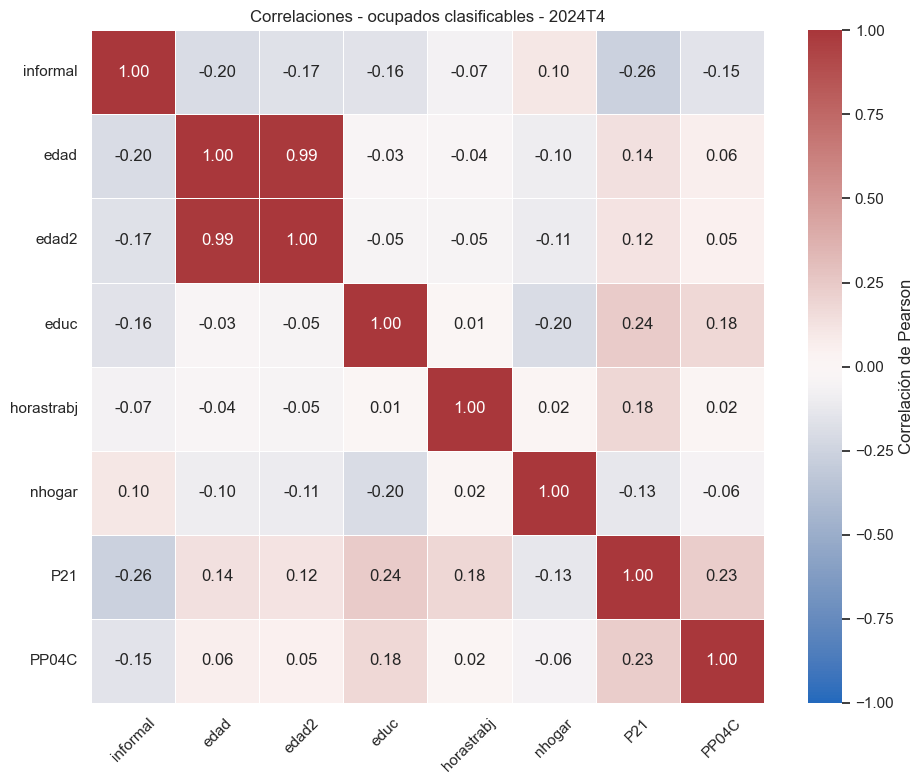

Matriz de correlación - 2025T4


,informal,edad,edad2,educ,horastrabj,nhogar,P21,PP04C
informal,1.000,-0.188,-0.162,-0.144,-0.027,0.100,-0.248,-0.135
edad,-0.188,1.000,0.987,-0.059,-0.048,-0.095,0.140,0.070
edad2,-0.162,0.987,1.000,-0.073,-0.058,-0.100,0.122,0.056
educ,-0.144,-0.059,-0.073,1.000,-0.007,-0.189,0.260,0.166
horastrabj,-0.027,-0.048,-0.058,-0.007,1.000,0.016,0.123,0.006
nhogar,0.100,-0.095,-0.100,-0.189,0.016,1.000,-0.132,-0.026
P21,-0.248,0.140,0.122,0.260,0.123,-0.132,1.000,0.224
PP04C,-0.135,0.070,0.056,0.166,0.006,-0.026,0.224,1.000


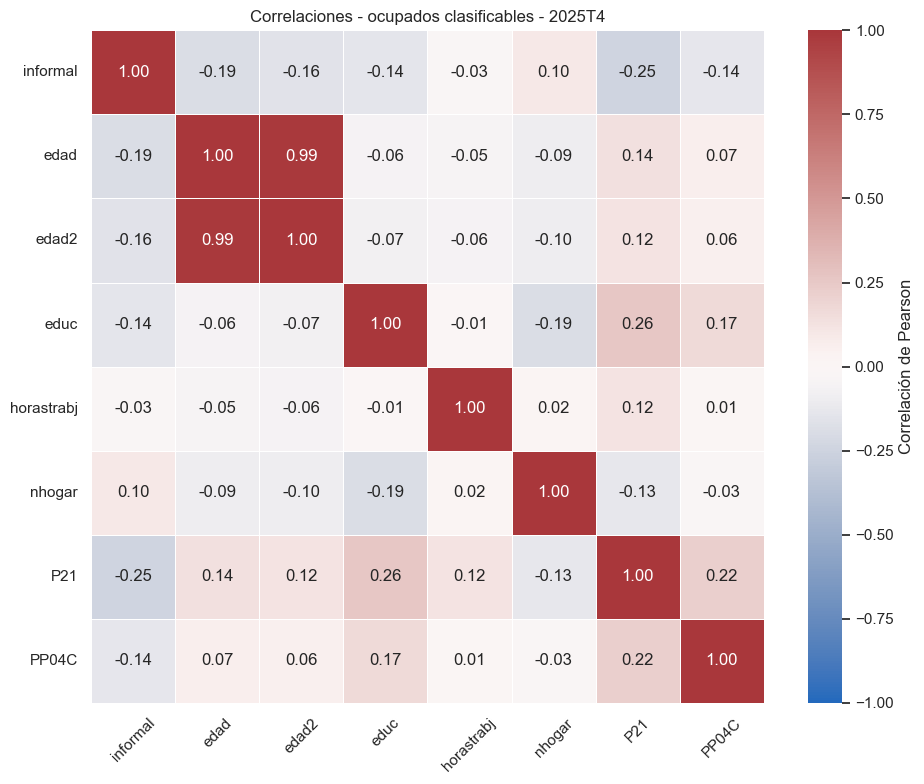

Correlaciones parciales con informalidad:


,Año,Predictor,Correlación parcial,Observaciones completas,Fuerza
0,2024,edad,-0.166,6813,baja
1,2024,edad2,0.142,6813,baja
2,2024,educ,-0.096,6813,baja
3,2024,horastrabj,-0.045,6813,baja
4,2024,nhogar,0.062,6813,baja
5,2024,P21,-0.188,6813,baja
6,2024,PP04C,-0.067,6813,baja
7,2025,edad,-0.167,6037,baja
8,2025,edad2,0.143,6037,baja
9,2025,educ,-0.086,6037,baja


Comparación de correlaciones parciales:


Año,r_parcial_2024,r_parcial_2025,Cambio,Cambio absoluto,Cambio >= 0.10
Predictor,,,,,
horastrabj,-0.045,-0.017,0.028,0.028,False
nhogar,0.062,0.077,0.015,0.015,False
educ,-0.096,-0.086,0.011,0.011,False
P21,-0.188,-0.180,0.008,0.008,False
PP04C,-0.067,-0.062,0.005,0.005,False
edad,-0.166,-0.167,-0.001,0.001,False
edad2,0.142,0.143,0.001,0.001,False


**Conclusión 2024.** El mayor valor absoluto de correlación parcial es 0.188; con la regla declarada, el contexto es de correlación **baja** entre los predictores y la informalidad.

**Conclusión 2025.** El mayor valor absoluto de correlación parcial es 0.180; con la regla declarada, el contexto es de correlación **baja** entre los predictores y la informalidad.

In [8]:
# ============================================================
# 7. MATRICES DE CORRELACIÓN Y CORRELACIONES PARCIALES
# ============================================================

VARIABLES_MODELOS = [
    "edad", "edad2", "educ", "horastrabj", "nhogar", "P21", "PP04C",
]
VARIABLES_CORR = ["informal"] + VARIABLES_MODELOS


def clasificar_fuerza(valor):
    valor = abs(valor)
    if valor < 0.30:
        return "baja"
    if valor < 0.60:
        return "mediana"
    return "alta"


def correlacion_parcial(base, objetivo, predictor, controles):
    columnas = [objetivo, predictor] + controles
    datos = base[columnas].dropna().copy()

    modelo_objetivo = LinearRegression()
    modelo_objetivo.fit(datos[controles], datos[objetivo])
    residuo_objetivo = (
        datos[objetivo] - modelo_objetivo.predict(datos[controles])
    )

    modelo_predictor = LinearRegression()
    modelo_predictor.fit(datos[controles], datos[predictor])
    residuo_predictor = (
        datos[predictor] - modelo_predictor.predict(datos[controles])
    )

    r_parcial = np.corrcoef(residuo_objetivo, residuo_predictor)[0, 1]
    return r_parcial, len(datos)


matrices_corr = {}
filas_parciales = []

for anio in [2024, 2025]:
    datos_anio = base_clasificada[
        base_clasificada["ANO4"] == anio
    ].copy()

    matriz = datos_anio[VARIABLES_CORR].corr(min_periods=50)
    matrices_corr[anio] = matriz

    print(f"Matriz de correlación - {anio}T4")
    display(matriz.round(3))

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        matriz,
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "Correlación de Pearson"},
        ax=ax,
    )
    ax.set_title(f"Correlaciones - ocupados clasificables - {anio}T4")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)
    plt.tight_layout()
    fig.savefig(
        CARPETA_SALIDA / f"parte_I_3_correlaciones_{anio}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    for predictor in VARIABLES_MODELOS:
        controles = [
            variable for variable in VARIABLES_MODELOS
            if variable != predictor
        ]
        r_parcial, n = correlacion_parcial(
            datos_anio,
            "informal",
            predictor,
            controles,
        )
        filas_parciales.append({
            "Año": anio,
            "Predictor": predictor,
            "Correlación parcial": r_parcial,
            "Observaciones completas": n,
            "Fuerza": clasificar_fuerza(r_parcial),
        })


correlaciones_parciales = pd.DataFrame(filas_parciales)
print("Correlaciones parciales con informalidad:")
display(correlaciones_parciales.round(3))

comparacion_parcial = (
    correlaciones_parciales
    .pivot(index="Predictor", columns="Año", values="Correlación parcial")
    .rename(columns={2024: "r_parcial_2024", 2025: "r_parcial_2025"})
)
comparacion_parcial["Cambio"] = (
    comparacion_parcial["r_parcial_2025"]
    - comparacion_parcial["r_parcial_2024"]
)
comparacion_parcial["Cambio absoluto"] = comparacion_parcial["Cambio"].abs()
comparacion_parcial["Cambio >= 0.10"] = (
    comparacion_parcial["Cambio absoluto"] >= 0.10
)

print("Comparación de correlaciones parciales:")
display(comparacion_parcial.sort_values("Cambio absoluto", ascending=False).round(3))

for anio in [2024, 2025]:
    serie = correlaciones_parciales.loc[
        correlaciones_parciales["Año"] == anio,
        "Correlación parcial",
    ]
    maximo = serie.abs().max()
    display(Markdown(
        f"**Conclusión {anio}.** El mayor valor absoluto de correlación parcial "
        f"es {maximo:.3f}; con la regla declarada, el contexto es de "
        f"correlación **{clasificar_fuerza(maximo)}** entre los predictores y "
        "la informalidad."
    ))


## Parte II. Métodos no supervisados

Se trabaja con formal wage employees e informal upper-tier wage employees, porque son las dos categorías comparables definidas para nuestro grupo. Para PCA, k-medias y Ward se eliminan los casos con algún faltante en las siete variables y se estandarizan las columnas


In [9]:
# ============================================================
# 8. BASE COMPLETA Y ESTANDARIZACIÓN
# ============================================================

base_metodos = base_clasificada.dropna(subset=VARIABLES_MODELOS).copy()
base_metodos = base_metodos.reset_index(drop=True)
base_metodos["condicion"] = base_metodos["informal"].map({
    0: "Formal",
    1: "Informal upper-tier",
})

escalador = StandardScaler()
X_escalada = escalador.fit_transform(base_metodos[VARIABLES_MODELOS])

print("Casos disponibles para PCA y clúster numérico:", len(base_metodos))
print(
    "Casos clasificables eliminados por algún faltante:",
    len(base_clasificada) - len(base_metodos),
)


Casos disponibles para PCA y clúster numérico: 12850
Casos clasificables eliminados por algún faltante: 8647


### A. PCA

#### 1. Scores del primer y segundo componente


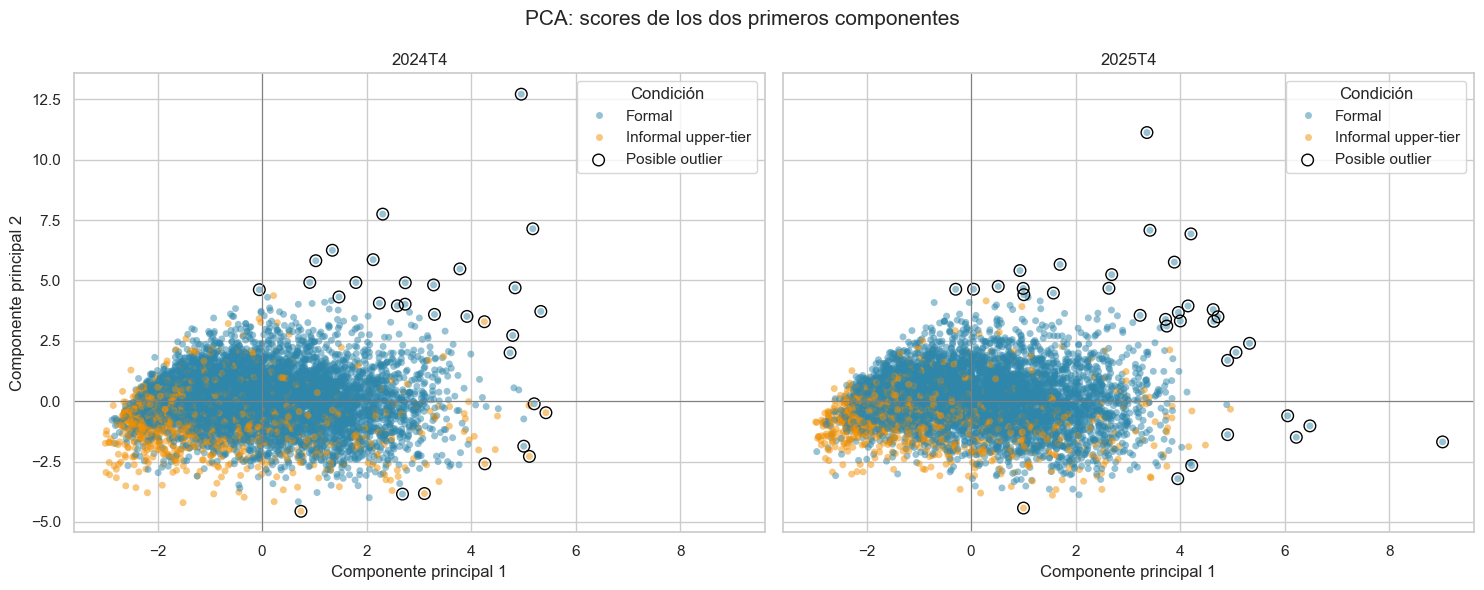

Posibles outliers por año:


,sum,mean
ANO4,,
2024,31,0.005
2025,34,0.006


Promedio de PC1 y PC2 por condición:


,PC1,PC2
condicion,,
Formal,0.144,0.131
Informal upper-tier,-0.754,-0.684


In [10]:
# ============================================================
# 9. PCA: SCORES Y POSIBLES OUTLIERS
# ============================================================

pca = PCA(n_components=len(VARIABLES_MODELOS))
scores = pca.fit_transform(X_escalada)

for numero in range(1, len(VARIABLES_MODELOS) + 1):
    base_metodos[f"PC{numero}"] = scores[:, numero - 1]

# Distancia estandarizada en el plano PC1-PC2.
distancia_pc = (
    base_metodos["PC1"] ** 2 / pca.explained_variance_[0]
    + base_metodos["PC2"] ** 2 / pca.explained_variance_[1]
)
umbral_outlier = distancia_pc.quantile(0.995)
base_metodos["outlier_pca"] = distancia_pc > umbral_outlier

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

for ax, anio in zip(axes, [2024, 2025]):
    datos_anio = base_metodos[base_metodos["ANO4"] == anio]

    sns.scatterplot(
        data=datos_anio,
        x="PC1",
        y="PC2",
        hue="condicion",
        palette=COLORES_FORMALIDAD,
        alpha=0.50,
        s=25,
        linewidth=0,
        ax=ax,
    )

    outliers = datos_anio[datos_anio["outlier_pca"]]
    ax.scatter(
        outliers["PC1"],
        outliers["PC2"],
        facecolors="none",
        edgecolors="black",
        s=70,
        linewidth=1,
        label="Posible outlier",
    )

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    ax.set_title(f"{anio}T4")
    ax.set_xlabel("Componente principal 1")
    ax.set_ylabel("Componente principal 2")
    ax.legend(title="Condición")

fig.suptitle("PCA: scores de los dos primeros componentes", fontsize=15)
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_A_1_scores_pca.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Posibles outliers por año:")
display(base_metodos.groupby("ANO4")["outlier_pca"].agg(["sum", "mean"]))

print("Promedio de PC1 y PC2 por condición:")
display(
    base_metodos
    .groupby("condicion")[["PC1", "PC2"]]
    .mean()
    .round(3)
)


#### 2. Ponderadores y biplot

Las flechas usan un único factor de escala para ambos ejes. Así se preservan la dirección y los ángulos relativos de los ponderadores.


Ponderadores de PC1 y PC2:


,PC1,PC2
edad,0.681,-0.150
edad2,0.679,-0.166
educ,0.028,0.570
horastrabj,-0.029,0.183
nhogar,-0.101,-0.331
P21,0.222,0.533
PP04C,0.118,0.444


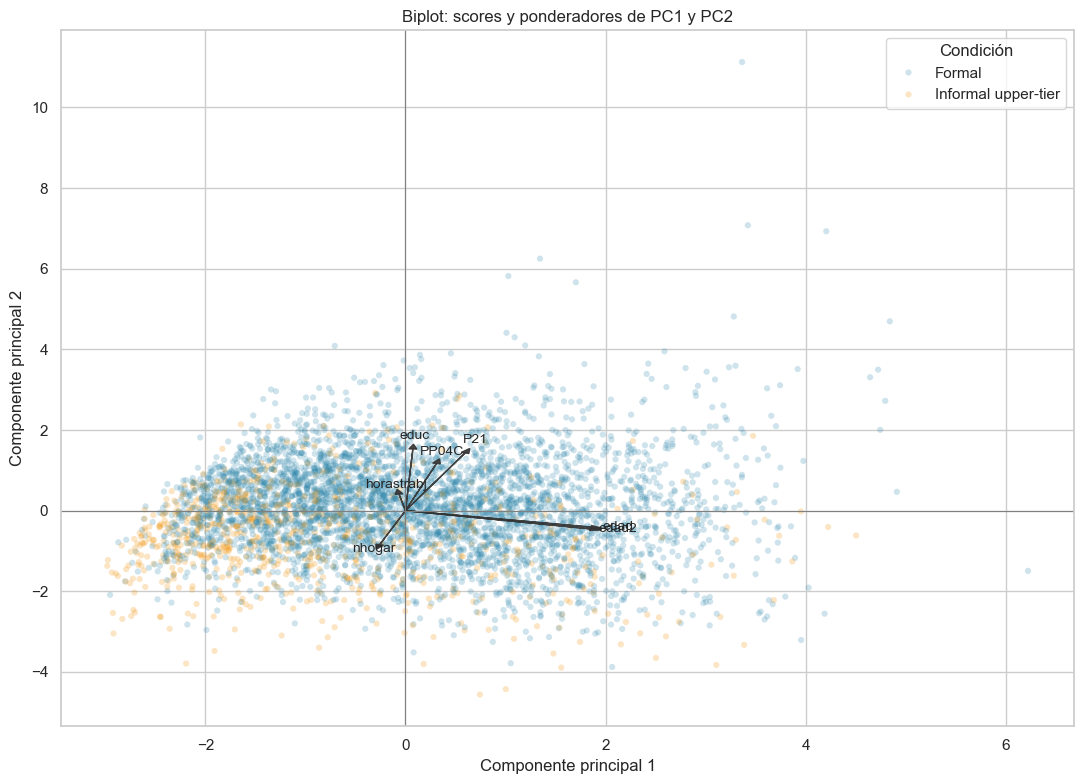

Mayores pesos absolutos de PC1: edad (0.681) y edad2 (0.679).
Mayores pesos absolutos de PC2: educ (0.570) y P21 (0.533).


In [11]:
# ============================================================
# 10. PCA: PONDERADORES Y BIPLOT
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=VARIABLES_MODELOS,
    columns=[f"PC{i}" for i in range(1, len(VARIABLES_MODELOS) + 1)],
)

print("Ponderadores de PC1 y PC2:")
display(loadings[["PC1", "PC2"]].round(3))

if len(base_metodos) > 5000:
    puntos_biplot = base_metodos.sample(5000, random_state=SEMILLA)
else:
    puntos_biplot = base_metodos.copy()

fig, ax = plt.subplots(figsize=(11, 8))

sns.scatterplot(
    data=puntos_biplot,
    x="PC1",
    y="PC2",
    hue="condicion",
    palette=COLORES_FORMALIDAD,
    alpha=0.23,
    s=20,
    linewidth=0,
    ax=ax,
)

limite_x = np.quantile(np.abs(base_metodos["PC1"]), 0.95)
limite_y = np.quantile(np.abs(base_metodos["PC2"]), 0.95)
escala_flechas = 0.75 * min(
    limite_x / loadings["PC1"].abs().max(),
    limite_y / loadings["PC2"].abs().max(),
)

for variable in VARIABLES_MODELOS:
    x = loadings.loc[variable, "PC1"] * escala_flechas
    y = loadings.loc[variable, "PC2"] * escala_flechas

    ax.arrow(
        0,
        0,
        x,
        y,
        color="#333333",
        alpha=0.9,
        head_width=0.08,
        length_includes_head=True,
    )
    ax.text(x * 1.08, y * 1.08, variable, fontsize=10, ha="center")

ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_title("Biplot: scores y ponderadores de PC1 y PC2")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.legend(title="Condición")

plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_A_2_biplot.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

for componente in ["PC1", "PC2"]:
    orden = loadings[componente].abs().sort_values(ascending=False)
    print(
        f"Mayores pesos absolutos de {componente}: "
        f"{orden.index[0]} ({loadings.loc[orden.index[0], componente]:.3f}) y "
        f"{orden.index[1]} ({loadings.loc[orden.index[1], componente]:.3f})."
    )


#### 3. Proporción de varianza explicada


,Componente,Proporción,Acumulada
0,1,0.293,0.293
1,2,0.214,0.507
2,3,0.153,0.660
3,4,0.137,0.797
4,5,0.107,0.903
5,6,0.095,0.998
6,7,0.002,1.000


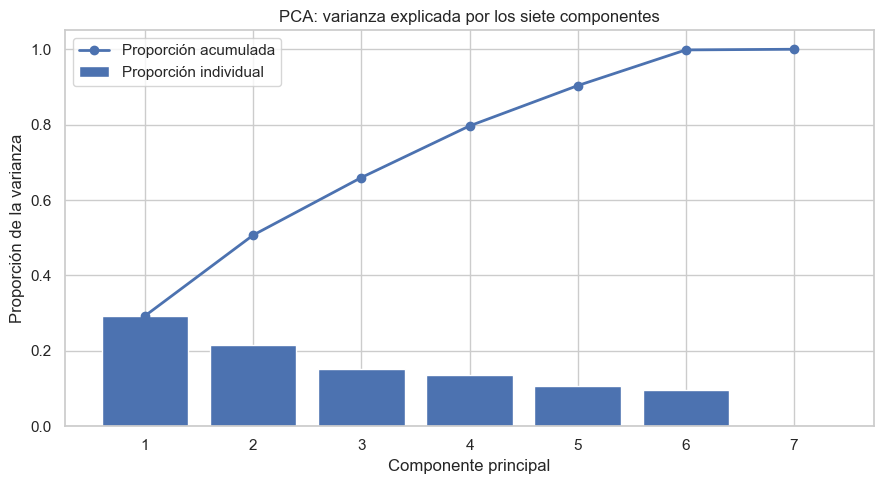

Los dos primeros componentes explican 50.7% de la variación.


In [12]:
# ============================================================
# 11. PCA: VARIANZA EXPLICADA
# ============================================================

varianza = pd.DataFrame({
    "Componente": np.arange(1, len(VARIABLES_MODELOS) + 1),
    "Proporción": pca.explained_variance_ratio_,
})
varianza["Acumulada"] = varianza["Proporción"].cumsum()

display(varianza.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(
    varianza["Componente"],
    varianza["Proporción"],
    label="Proporción individual",
)
ax.plot(
    varianza["Componente"],
    varianza["Acumulada"],
    marker="o",
    linewidth=2,
    label="Proporción acumulada",
)
ax.set_xticks(varianza["Componente"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Componente principal")
ax.set_ylabel("Proporción de la varianza")
ax.set_title("PCA: varianza explicada por los siete componentes")
ax.legend()
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_A_3_varianza_explicada.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Los dos primeros componentes explican",
    f"{varianza.loc[1, 'Acumulada'] * 100:.1f}% de la variación."
)


### B. Clúster

#### 4.a. K-medias con k = 2 y n_init = 20


In [13]:
# ============================================================
# 12. FUNCIONES DE EVALUACIÓN DE CLÚSTERES BINARIOS
# ============================================================


def evaluar_clusters_binarios(etiquetas_reales, clusters):
    y = np.asarray(etiquetas_reales, dtype=int)
    c = np.asarray(clusters, dtype=int)

    prediccion_directa = c
    prediccion_invertida = 1 - c

    exactitud_directa = balanced_accuracy_score(y, prediccion_directa)
    exactitud_invertida = balanced_accuracy_score(y, prediccion_invertida)

    if exactitud_directa >= exactitud_invertida:
        prediccion_alineada = prediccion_directa
    else:
        prediccion_alineada = prediccion_invertida

    tabla_conteos = pd.crosstab(
        pd.Series(c, name="Clúster"),
        pd.Series(y, name="Informal"),
    )
    tabla_proporciones = pd.crosstab(
        pd.Series(c, name="Clúster"),
        pd.Series(y, name="Informal"),
        normalize="index",
    )

    return {
        "Exactitud balanceada": balanced_accuracy_score(y, prediccion_alineada),
        "ARI": adjusted_rand_score(y, c),
        "Conteos": tabla_conteos,
        "Proporciones": tabla_proporciones,
    }


Conteos por clúster y condición:


Informal,0,1
Clúster,,
0,5747,1535
1,5042,526


Proporciones dentro de cada clúster:


Informal,0,1
Clúster,,
0,0.789,0.211
1,0.906,0.094


Exactitud balanceada: 0.606
ARI: -0.008


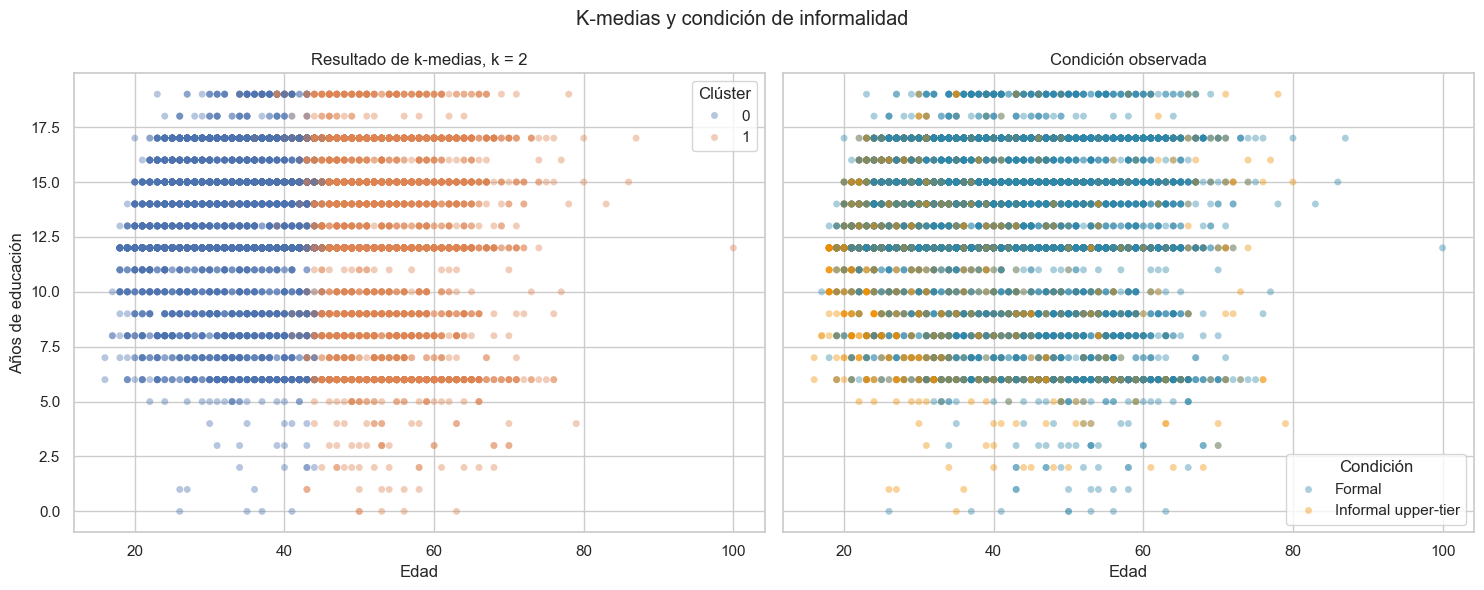

In [14]:
# ============================================================
# 13. K-MEDIAS CON K = 2
# ============================================================

kmeans_2 = KMeans(
    n_clusters=2,
    n_init=20,
    random_state=SEMILLA,
)
base_metodos["cluster_kmeans"] = kmeans_2.fit_predict(X_escalada)

evaluacion_kmeans = evaluar_clusters_binarios(
    base_metodos["informal"],
    base_metodos["cluster_kmeans"],
)

print("Conteos por clúster y condición:")
display(evaluacion_kmeans["Conteos"])
print("Proporciones dentro de cada clúster:")
display(evaluacion_kmeans["Proporciones"].round(3))
print("Exactitud balanceada:", round(evaluacion_kmeans["Exactitud balanceada"], 3))
print("ARI:", round(evaluacion_kmeans["ARI"], 3))

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=base_metodos,
    x="edad",
    y="educ",
    hue="cluster_kmeans",
    alpha=0.40,
    s=25,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("Resultado de k-medias, k = 2")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Años de educación")
axes[0].legend(title="Clúster")

sns.scatterplot(
    data=base_metodos,
    x="edad",
    y="educ",
    hue="condicion",
    palette=COLORES_FORMALIDAD,
    alpha=0.40,
    s=25,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Condición observada")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Años de educación")
axes[1].legend(title="Condición")

fig.suptitle("K-medias y condición de informalidad")
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_4a_kmeans_2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


#### 4.b. Método de Elbow para k = 1, ..., 40




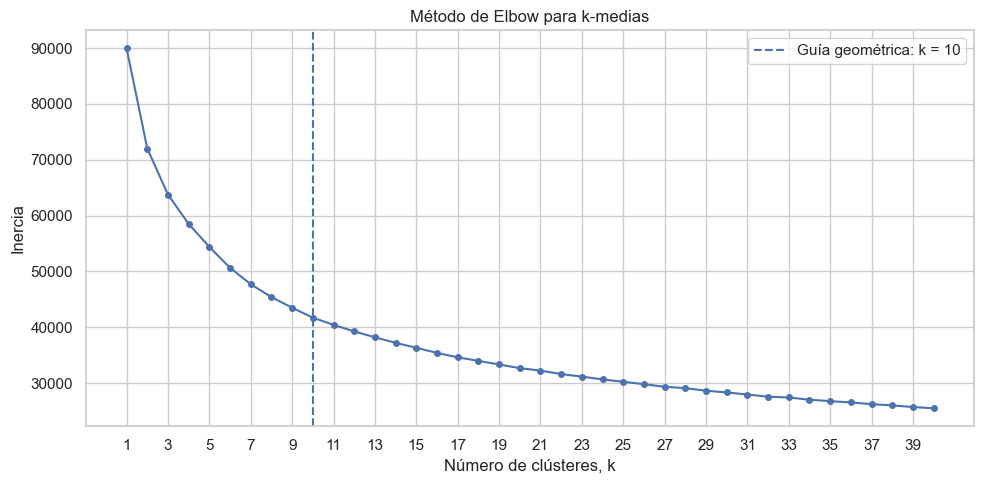

Codo sugerido como ayuda visual: 10


In [15]:
# ============================================================
# 14. K-MEDIAS: MÉTODO DE ELBOW
# ============================================================


def codo_por_distancia(valores_k, costos):
    x = np.asarray(valores_k, dtype=float)
    y = np.asarray(costos, dtype=float)

    x_normalizado = (x - x.min()) / (x.max() - x.min())
    y_normalizado = (y - y.min()) / (y.max() - y.min())

    linea = np.array([
        x_normalizado[-1] - x_normalizado[0],
        y_normalizado[-1] - y_normalizado[0],
    ])
    puntos = np.column_stack([
        x_normalizado - x_normalizado[0],
        y_normalizado - y_normalizado[0],
    ])

    distancias = np.abs(
        linea[0] * puntos[:, 1] - linea[1] * puntos[:, 0]
    )
    distancias = distancias / np.sqrt((linea ** 2).sum())

    return int(valores_k[np.argmax(distancias)])


valores_k_kmeans = list(range(1, 41))
inercias_kmeans = []

for k in valores_k_kmeans:
    modelo = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=SEMILLA,
    )
    modelo.fit(X_escalada)
    inercias_kmeans.append(modelo.inertia_)

k_sugerido_kmeans = codo_por_distancia(
    valores_k_kmeans,
    inercias_kmeans,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(valores_k_kmeans, inercias_kmeans, marker="o", markersize=4)
ax.axvline(
    k_sugerido_kmeans,
    linestyle="--",
    label=f"Guía geométrica: k = {k_sugerido_kmeans}",
)
ax.set_xticks(range(1, 41, 2))
ax.set_xlabel("Número de clústeres, k")
ax.set_ylabel("Inercia")
ax.set_title("Método de Elbow para k-medias")
ax.legend()
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_4b_elbow_kmeans.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Codo sugerido como ayuda visual:", k_sugerido_kmeans)


#### 5. Clúster jerárquico

El dendrograma muestra cómo las observaciones se fusionan progresivamente. La altura de cada unión representa la distancia a la que ocurre la fusión. Ward requiere una matriz de distancias que crece rápidamente con el número de casos. Por eso tomamos una muestra aleatoria reproducible, sin usar la condición de informalidad para seleccionar observaciones.


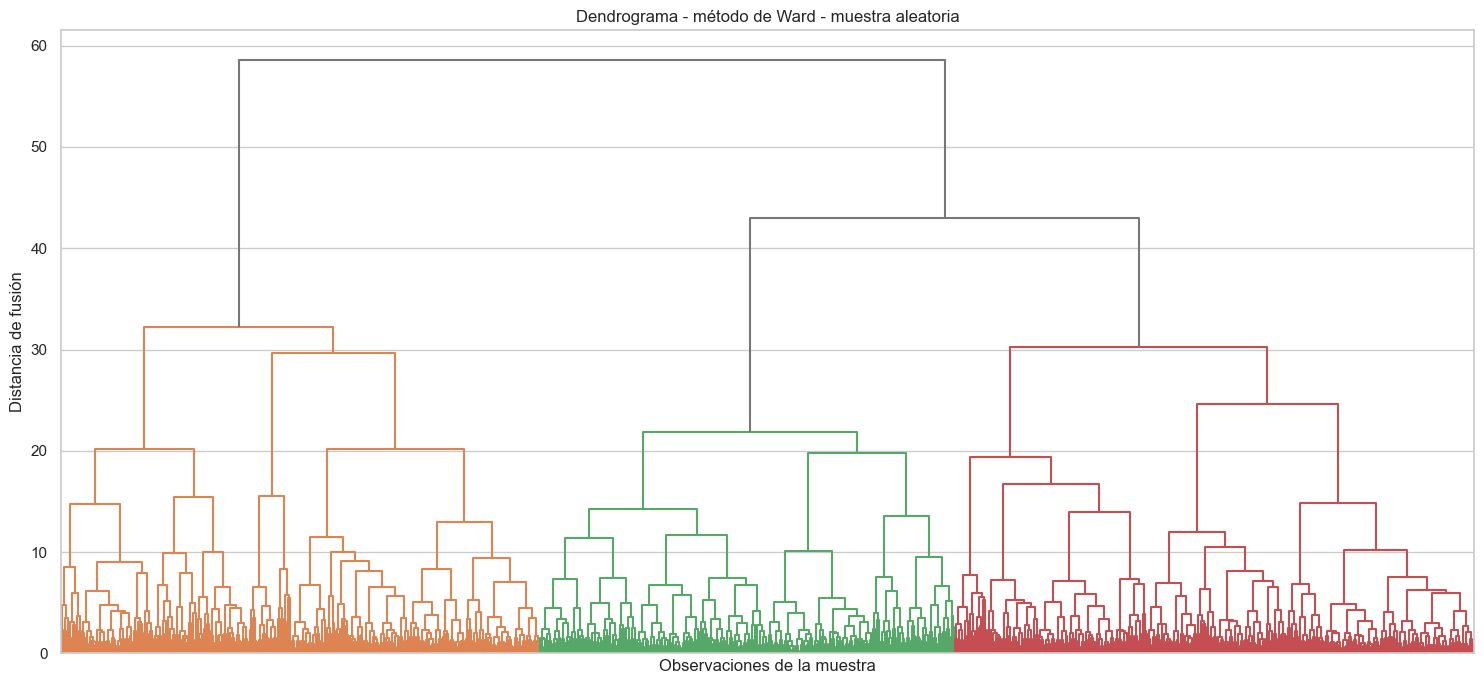

Composición de dos clústeres jerárquicos:


Informal,0,1
Clúster,,
0,0.856,0.144
1,0.839,0.161


ARI jerárquico: -0.007


In [16]:
# ============================================================
# 15. CLÚSTER JERÁRQUICO Y DENDROGRAMA
# ============================================================

cantidad_jerarquico = min(1500, len(base_metodos))
base_jerarquico = base_metodos.sample(
    cantidad_jerarquico,
    random_state=SEMILLA,
).copy()

# Como base_metodos fue reiniciada, sus índices identifican filas de X_escalada.
X_jerarquico = X_escalada[base_jerarquico.index]
matriz_linkage = linkage(X_jerarquico, method="ward")

fig, ax = plt.subplots(figsize=(15, 7))
dendrogram(
    matriz_linkage,
    no_labels=True,
    color_threshold=None,
    above_threshold_color="#777777",
    ax=ax,
)
ax.set_title("Dendrograma - método de Ward - muestra aleatoria")
ax.set_xlabel("Observaciones de la muestra")
ax.set_ylabel("Distancia de fusión")
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_5_dendrograma.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

cluster_jerarquico_2 = fcluster(
    matriz_linkage,
    t=2,
    criterion="maxclust",
) - 1

evaluacion_jerarquico = evaluar_clusters_binarios(
    base_jerarquico["informal"],
    cluster_jerarquico_2,
)

print("Composición de dos clústeres jerárquicos:")
display(evaluacion_jerarquico["Proporciones"].round(3))
print("ARI jerárquico:", round(evaluacion_jerarquico["ARI"], 3))


#### 6.a. K-moda con k = 2

K-moda usa disimilitud de coincidencias. Cada desacuerdo de categoría suma una unidad. Se incorporan las dummies del TP1 y las cuatro variables nuevas categorizadas. Las columnas constantes se eliminan porque no pueden ayudar a formar grupos


In [17]:
# ============================================================
# 16. CATEGORIZACIÓN PARA K-MODA
# ============================================================

base_kmodes = base_clasificada.copy()

base_kmodes["edad2_cat"] = pd.cut(
    base_kmodes["edad2"],
    bins=[-1, 29 ** 2, 39 ** 2, 49 ** 2, 64 ** 2, np.inf],
    labels=["Hasta 29", "30 a 39", "40 a 49", "50 a 64", "65 o más"],
)

base_kmodes["educ_cat"] = pd.cut(
    base_kmodes["educ"],
    bins=[-1, 6, 9, 12, 16, np.inf],
    labels=["Hasta 6", "7 a 9", "10 a 12", "13 a 16", "17 o más"],
)

base_kmodes["horastrabj_cat"] = pd.cut(
    base_kmodes["horastrabj"],
    bins=[-1, 0, 34, 45, 60, np.inf],
    labels=["0", "1 a 34", "35 a 45", "46 a 60", "Más de 60"],
)

base_kmodes["nhogar_cat"] = pd.cut(
    base_kmodes["nhogar"],
    bins=[0, 1, 2, 4, np.inf],
    labels=["1", "2", "3 o 4", "5 o más"],
)

VARIABLES_NUEVAS_CATEGORIZADAS = [
    "edad2_cat", "educ_cat", "horastrabj_cat", "nhogar_cat",
]
VARIABLES_KMODES_INICIALES = (
    VARIABLES_DUMMY_TP1 + VARIABLES_NUEVAS_CATEGORIZADAS
)

X_kmodes = base_kmodes[VARIABLES_KMODES_INICIALES].copy()
X_kmodes = X_kmodes.astype("string").fillna("Faltante")

variables_constantes = [
    variable for variable in X_kmodes.columns
    if X_kmodes[variable].nunique() <= 1
]
X_kmodes = X_kmodes.drop(columns=variables_constantes)

print("Variables constantes eliminadas:", variables_constantes)
print("Variables finalmente usadas:")
print(X_kmodes.columns.tolist())
print("Dimensión de la matriz categórica:", X_kmodes.shape)
assert "informal" not in X_kmodes.columns


Variables constantes eliminadas: ['asalariado', 'cuenta_propia']
Variables finalmente usadas:
['mujer', 'casado', 'unido_o_casado', 'con_cobertura_medica', 'secundario_completo_o_mas', 'empleo_informal_eph', 'sector_informal', 'sector_publico', 'ocupado_pleno', 'con_descuento_jubilatorio', 'sin_descuento_jubilatorio', 'edad2_cat', 'educ_cat', 'horastrabj_cat', 'nhogar_cat']
Dimensión de la matriz categórica: (21497, 15)


In [18]:
# ============================================================
# 17. FUNCIÓN K-MODA SIN PAQUETES EXTERNOS
# ============================================================


def kmodes_simple(
    datos,
    n_clusters,
    n_init=10,
    max_iter=50,
    random_state=123,
):
    matriz = datos.astype(str).to_numpy(dtype=object)
    n_observaciones, n_variables = matriz.shape

    generador_general = np.random.default_rng(random_state)
    mejor_resultado = None

    for repeticion in range(n_init):
        semilla_repeticion = generador_general.integers(0, 2 ** 32 - 1)
        generador = np.random.default_rng(semilla_repeticion)

        indices_iniciales = generador.choice(
            n_observaciones,
            size=n_clusters,
            replace=False,
        )
        modos = matriz[indices_iniciales].copy()
        etiquetas = np.full(n_observaciones, -1, dtype=int)

        for iteracion in range(max_iter):
            distancias = (
                matriz[:, None, :] != modos[None, :, :]
            ).sum(axis=2)
            nuevas_etiquetas = distancias.argmin(axis=1)

            if np.array_equal(nuevas_etiquetas, etiquetas):
                etiquetas = nuevas_etiquetas
                break

            etiquetas = nuevas_etiquetas

            for cluster in range(n_clusters):
                miembros = matriz[etiquetas == cluster]

                if len(miembros) == 0:
                    modos[cluster] = matriz[
                        generador.integers(n_observaciones)
                    ]
                else:
                    for columna in range(n_variables):
                        valores, frecuencias = np.unique(
                            miembros[:, columna],
                            return_counts=True,
                        )
                        modos[cluster, columna] = valores[
                            frecuencias.argmax()
                        ]

        distancias_finales = (
            matriz[:, None, :] != modos[None, :, :]
        ).sum(axis=2)
        costo = distancias_finales[
            np.arange(n_observaciones),
            etiquetas,
        ].sum()

        if mejor_resultado is None or costo < mejor_resultado["costo"]:
            mejor_resultado = {
                "costo": int(costo),
                "etiquetas": etiquetas.copy(),
                "modos": modos.copy(),
                "iteraciones": iteracion + 1,
            }

    return mejor_resultado


Costo de k-moda: 97442
Proporciones dentro de cada clúster:


Informal,0,1
Clúster,,
0,0.837,0.163
1,0.889,0.111


Exactitud balanceada: 0.554
ARI: 0.001
Modas que describen a cada clúster:


,Clúster 0,Clúster 1
mujer,1,0
casado,0,0
unido_o_casado,0,1
con_cobertura_medica,1,1
secundario_completo_o_mas,1,1
empleo_informal_eph,0,0
sector_informal,0,0
sector_publico,0,0
ocupado_pleno,1,1
con_descuento_jubilatorio,1,1


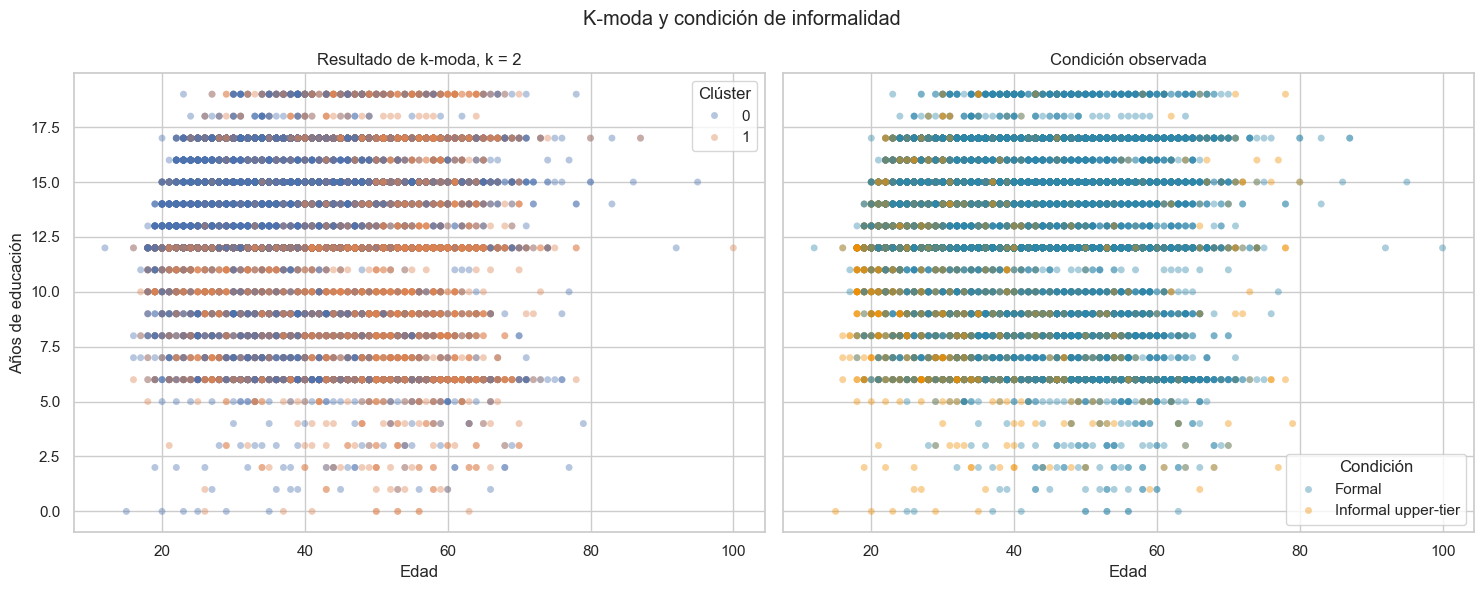

In [19]:
# ============================================================
# 18. K-MODA CON K = 2
# ============================================================

resultado_kmodes_2 = kmodes_simple(
    X_kmodes,
    n_clusters=2,
    n_init=10,
    random_state=SEMILLA,
)

base_kmodes["cluster_kmodes"] = resultado_kmodes_2["etiquetas"]

evaluacion_kmodes = evaluar_clusters_binarios(
    base_kmodes["informal"],
    base_kmodes["cluster_kmodes"],
)

print("Costo de k-moda:", resultado_kmodes_2["costo"])
print("Proporciones dentro de cada clúster:")
display(evaluacion_kmodes["Proporciones"].round(3))
print("Exactitud balanceada:", round(evaluacion_kmodes["Exactitud balanceada"], 3))
print("ARI:", round(evaluacion_kmodes["ARI"], 3))

modas_clusters = pd.DataFrame(
    resultado_kmodes_2["modos"],
    columns=X_kmodes.columns,
    index=["Clúster 0", "Clúster 1"],
).T

print("Modas que describen a cada clúster:")
display(modas_clusters)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)

sns.scatterplot(
    data=base_kmodes,
    x="edad",
    y="educ",
    hue="cluster_kmodes",
    alpha=0.40,
    s=25,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_title("Resultado de k-moda, k = 2")
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Años de educación")
axes[0].legend(title="Clúster")

sns.scatterplot(
    data=base_kmodes,
    x="edad",
    y="educ",
    hue="grupo_informalidad",
    palette=COLORES_FORMALIDAD,
    alpha=0.40,
    s=25,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_title("Condición observada")
axes[1].set_xlabel("Edad")
axes[1].set_ylabel("Años de educación")
axes[1].legend(title="Condición")

fig.suptitle("K-moda y condición de informalidad")
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_6a_kmodes_2.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


#### 6.b. Elbow para k-moda y comparación con k-medias

El modelo principal k = 2 usa todos los casos. Para estimar quince soluciones de k-moda en un tiempo razonable se usa una muestra aleatoria reproducible de hasta 5.000 casos, independiente de la informalidad. Los costos se presentan tal como fueron calculados: no se fuerza artificialmente una curva monótona.


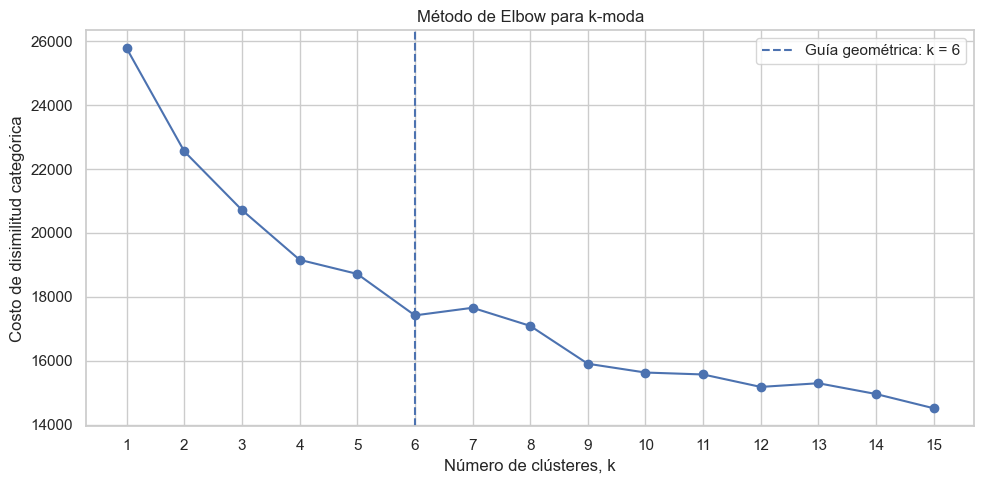

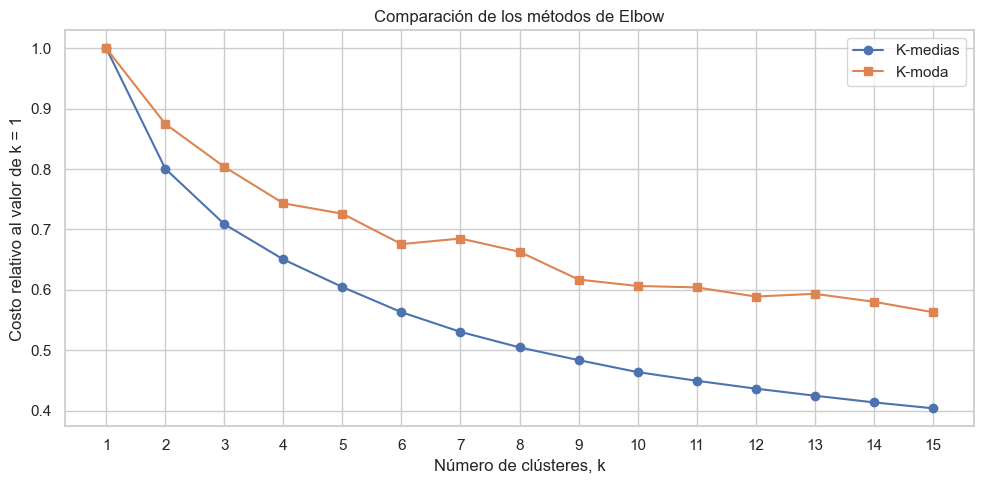

Codo sugerido para k-medias: 10
Codo sugerido para k-moda: 6


In [20]:
# ============================================================
# 19. K-MODA: ELBOW Y COMPARACIÓN CON K-MEDIAS
# ============================================================

if len(X_kmodes) > 5000:
    X_kmodes_elbow = X_kmodes.sample(5000, random_state=SEMILLA)
else:
    X_kmodes_elbow = X_kmodes.copy()

valores_k_kmodes = list(range(1, 16))
costos_kmodes = []

for k in valores_k_kmodes:
    resultado = kmodes_simple(
        X_kmodes_elbow,
        n_clusters=k,
        n_init=5,
        random_state=SEMILLA,
    )
    costos_kmodes.append(resultado["costo"])

k_sugerido_kmodes = codo_por_distancia(
    valores_k_kmodes,
    costos_kmodes,
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(valores_k_kmodes, costos_kmodes, marker="o")
ax.axvline(
    k_sugerido_kmodes,
    linestyle="--",
    label=f"Guía geométrica: k = {k_sugerido_kmodes}",
)
ax.set_xticks(valores_k_kmodes)
ax.set_xlabel("Número de clústeres, k")
ax.set_ylabel("Costo de disimilitud categórica")
ax.set_title("Método de Elbow para k-moda")
ax.legend()
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_6b_elbow_kmodes.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

comparacion_elbow = pd.DataFrame({
    "k": valores_k_kmodes,
    "K-medias (inercia normalizada)": (
        np.array(inercias_kmeans[:len(valores_k_kmodes)])
        / inercias_kmeans[0]
    ),
    "K-moda (costo normalizado)": (
        np.array(costos_kmodes) / costos_kmodes[0]
    ),
    "K-moda (costo bruto)": costos_kmodes,
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    comparacion_elbow["k"],
    comparacion_elbow["K-medias (inercia normalizada)"],
    marker="o",
    label="K-medias",
)
ax.plot(
    comparacion_elbow["k"],
    comparacion_elbow["K-moda (costo normalizado)"],
    marker="s",
    label="K-moda",
)
ax.set_xticks(valores_k_kmodes)
ax.set_xlabel("Número de clústeres, k")
ax.set_ylabel("Costo relativo al valor de k = 1")
ax.set_title("Comparación de los métodos de Elbow")
ax.legend()
plt.tight_layout()
fig.savefig(
    CARPETA_SALIDA / "parte_II_B_6b_comparacion_elbow.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Codo sugerido para k-medias:", k_sugerido_kmeans)
print("Codo sugerido para k-moda:", k_sugerido_kmodes)


### Exportación de tablas principales


In [21]:
# ============================================================
# 20. EXPORTACIÓN
# ============================================================

archivo_resultados = CARPETA_SALIDA / "tablas_tp2_grupo6_corregido.xlsx"

with pd.ExcelWriter(archivo_resultados, engine="openpyxl") as writer:
    tipos.to_excel(writer, sheet_name="tipos")
    tablas_descriptivas[2024].to_excel(writer, sheet_name="descriptiva_2024")
    tablas_descriptivas[2025].to_excel(writer, sheet_name="descriptiva_2025")
    matrices_corr[2024].to_excel(writer, sheet_name="correlaciones_2024")
    matrices_corr[2025].to_excel(writer, sheet_name="correlaciones_2025")
    correlaciones_parciales.to_excel(
        writer,
        sheet_name="corr_parciales",
        index=False,
    )
    comparacion_parcial.to_excel(writer, sheet_name="cambio_corr_parcial")
    loadings.to_excel(writer, sheet_name="loadings_pca")
    varianza.to_excel(writer, sheet_name="varianza_pca", index=False)
    evaluacion_kmeans["Proporciones"].to_excel(writer, sheet_name="kmeans_k2")
    evaluacion_jerarquico["Proporciones"].to_excel(
        writer,
        sheet_name="jerarquico_k2",
    )
    evaluacion_kmodes["Proporciones"].to_excel(writer, sheet_name="kmodes_k2")
    modas_clusters.to_excel(writer, sheet_name="modas_kmodes")
    comparacion_elbow.to_excel(
        writer,
        sheet_name="comparacion_elbow",
        index=False,
    )

print("Tablas guardadas en:", archivo_resultados)
print("Gráficos guardados en:", CARPETA_SALIDA)


Tablas guardadas en: salidas_tp2_corregido\tablas_tp2_grupo6_corregido.xlsx
Gráficos guardados en: salidas_tp2_corregido
